# Customer Purchasing Pattern Analysis using Python


## Project Overview
##### This project performs Exploratory Data Analysis (EDA) on a large customer purchasing dataset containing 10,000+ records.The goal is to identify:
##### 1.purchasing behavior
##### 2.customer trends
##### 3.high-value customers
##### 4.seasonal sales patterns
##### 5.outliers
##### 6.correlations between variables
## The project uses:
##### Python
##### Pandas
NumPy
Matplotlib
Seaborn

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
# Load Dataset
df = pd.read_csv('d:\Anacoda_3\customer_shopping_data.csv')


In [14]:
# Display first rows
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [15]:
df.tail()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park
99456,I232867,C273973,Female,36,Souvenir,3,35.19,Credit Card,15/10/2022,Mall of Istanbul


In [17]:
df.shape

(99457, 10)

In [18]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [19]:
# Statistical Summary
df.describe()


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [20]:
# Check Missing Values
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [21]:
# Remove Duplicates
df.drop_duplicates(inplace=True)


In [22]:
# Convert Date Column
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')

In [23]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


In [24]:
#Count total purchase by gender
gender_count = df['gender'].value_counts().reset_index()
gender_count

,gender,count
0,Female,59482
1,Male,39975


In [25]:
# Analyze customer age distribution
ages = df['age'].value_counts().reset_index()
ages.head()

,age,count
0,37,2057
1,22,2051
2,64,2002
3,43,2000
4,51,1993


In [26]:
# Find total unique product categories
df['category'].nunique()

8

In [27]:
# Count frequency of each product category
categories = df['category'].value_counts().reset_index()
categories

,category,count
0,Clothing,34487
1,Cosmetics,15097
2,Food & Beverage,14776
3,Toys,10087
4,Shoes,10034
5,Souvenir,4999
6,Technology,4996
7,Books,4981


In [28]:
# Analyze category purchases based on gender
categories_gender = df.groupby('category')['gender'].value_counts().reset_index()
categories_gender.head()

,category,gender,count
0,Books,Female,2906
1,Books,Male,2075
2,Clothing,Female,20652
3,Clothing,Male,13835
4,Cosmetics,Female,9070


In [29]:
# Analyze product category preferences by age
categories_age = df.groupby('age')['category'].value_counts().reset_index()
categories_age.head()

,age,category,count
0,18,Clothing,646
1,18,Food & Beverage,281
2,18,Cosmetics,267
3,18,Toys,176
4,18,Shoes,171


In [30]:
# Calculate total category purchases for each age group
categories_age.groupby(['age'])['count'].sum().head().reset_index()

,age,count
0,18,1844
1,19,1936
2,20,1844
3,21,1947
4,22,2051


In [31]:
# Calculate frequency of customer ages
ages_freq = df['age'].value_counts().reset_index()
ages_freq.head()

,age,count
0,37,2057
1,22,2051
2,64,2002
3,43,2000
4,51,1993


In [32]:
# Count usage frequency of payment methods
payment_methods = df['payment_method'].value_counts().reset_index()
payment_methods

,payment_method,count
0,Cash,44447
1,Credit Card,34931
2,Debit Card,20079


In [33]:
# Analyze payment methods based on gender
payment_gender =  df.groupby('payment_method')['gender'].value_counts().reset_index()
payment_gender

,payment_method,gender,count
0,Cash,Female,26509
1,Cash,Male,17938
2,Credit Card,Female,21011
3,Credit Card,Male,13920
4,Debit Card,Female,11962
5,Debit Card,Male,8117


In [34]:
# Find total number of unique shopping malls
df['shopping_mall'].nunique()

10

In [35]:
# Count transactions from each shopping mall
shopping_malls = df['shopping_mall'].value_counts().reset_index()
shopping_malls

,shopping_mall,count
0,Mall of Istanbul,19943
1,Kanyon,19823
2,Metrocity,15011
3,Metropol AVM,10161
4,Istinye Park,9781
5,Zorlu Center,5075
6,Cevahir AVM,4991
7,Forum Istanbul,4947
8,Viaport Outlet,4914
9,Emaar Square Mall,4811


In [36]:
# Calculate average product price by category
avg_price = df.groupby('category')['price'].mean().reset_index()
avg_price

,category,price
0,Books,45.568621
1,Clothing,901.084021
2,Cosmetics,122.448626
3,Food & Beverage,15.671948
4,Shoes,1807.388568
5,Souvenir,34.894345
6,Technology,3156.935548
7,Toys,107.733185


In [37]:
# Feature Engineering
df['Month'] = df['invoice_date'].dt.month
df['Year'] = df['invoice_date'].dt.year


In [38]:
# Total Sales by Category
category_sales = df.groupby('category')['price'].sum().sort_values(ascending=False)


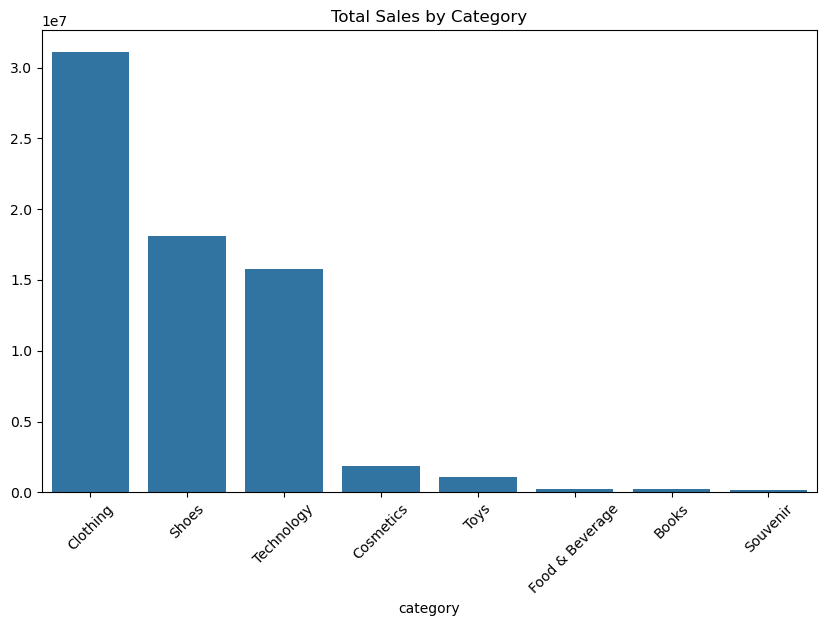

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Category")
plt.xticks(rotation=45)
plt.show()


In [39]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month')['price'].sum()


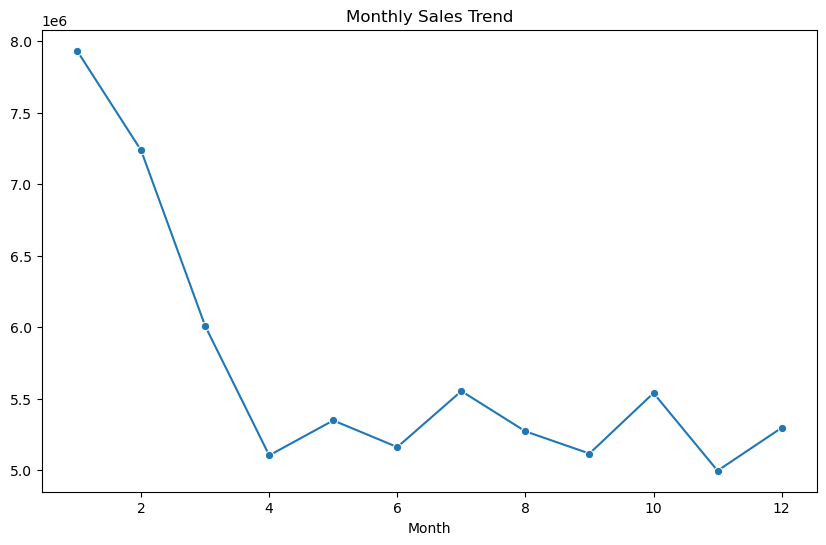

In [40]:
plt.figure(figsize=(10,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.show()

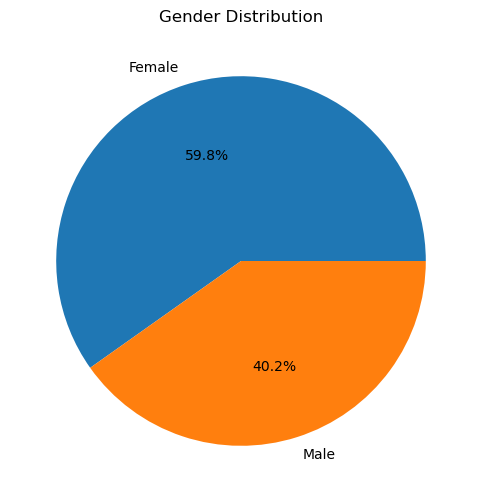

In [41]:
# Gender Distribution
plt.figure(figsize=(6,6))
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

Text(0, 0.5, 'count')

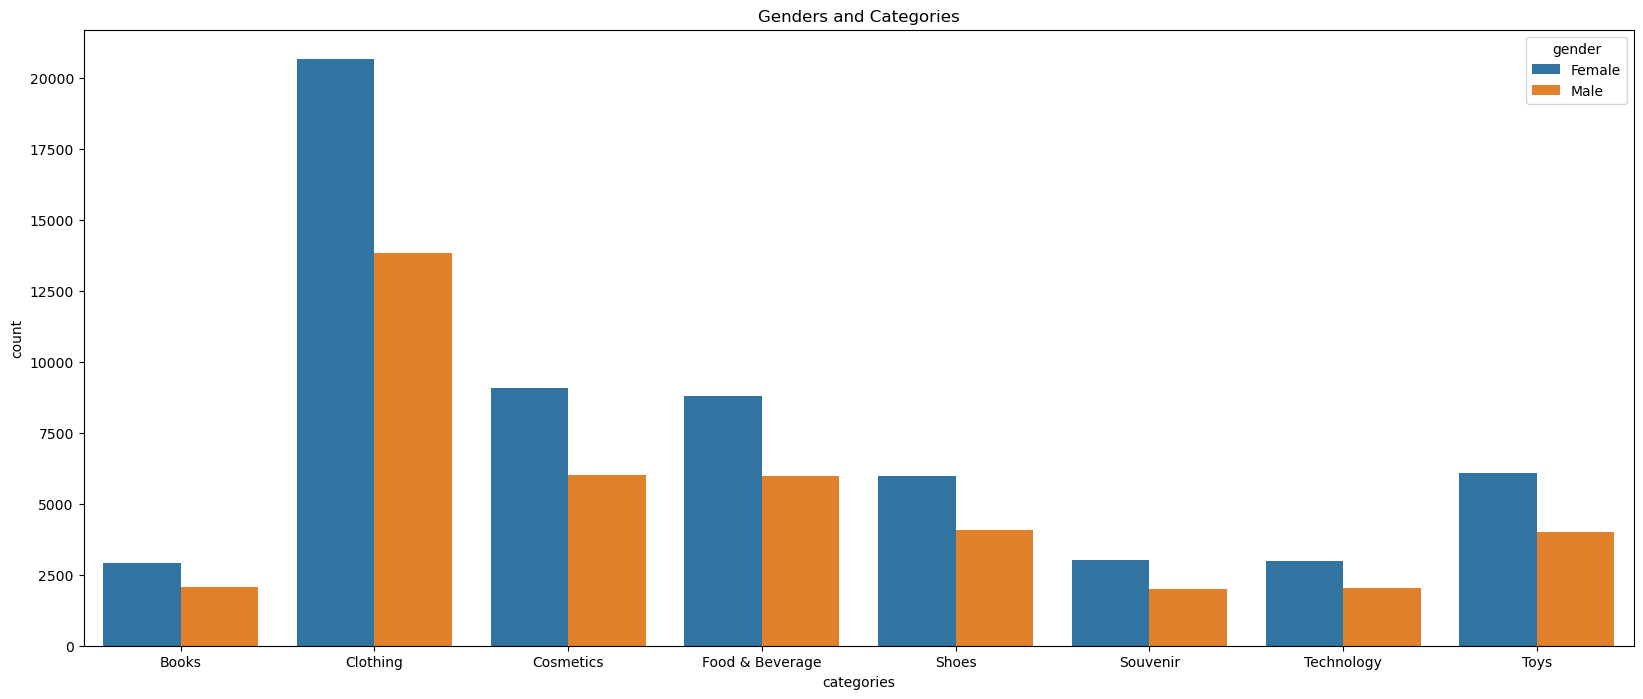

In [42]:
#Gender and Categories
plt.figure(figsize=(20,8))
plt.title('Genders and Categories')
sns.barplot(x='category',y='count',data=categories_gender, hue='gender')
plt.xlabel('categories')
plt.ylabel('count')


(np.float64(-1.1023152826884433),
 np.float64(1.1486208790715828),
 np.float64(-1.1044316485654115),
 np.float64(1.1930643178020843))

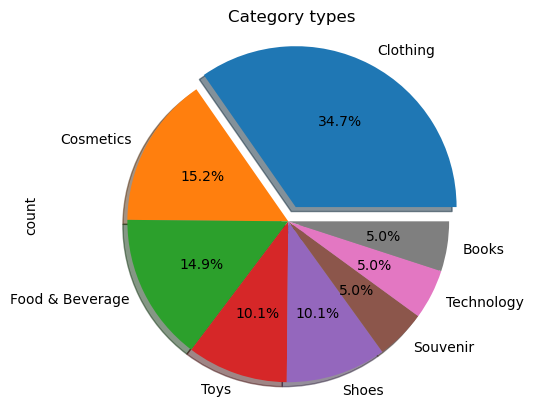

In [43]:
#Categories Types
l=['Clothing','Cosmetics','Food & Beverage','Toys','Shoes','Souvenir','Technology','Books']
categories.plot.pie(y='count',shadow=True, autopct='%1.1f%%',labels=l, legend=0, explode=[0.1,0,0,0,0,0,0,0])
plt.title('Category types')
plt.axis('equal')

Text(0.5, 1.0, 'Genders')

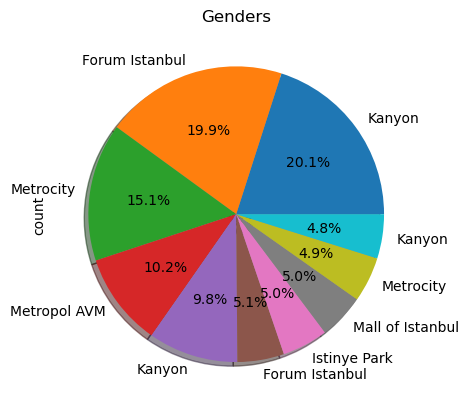

In [44]:
# Gender
shopping_malls.plot.pie(y='count', shadow=True, autopct='%1.1f%%',legend=0,labels=df['shopping_mall'])
plt.title('Genders')

Text(0, 0.5, 'Price')

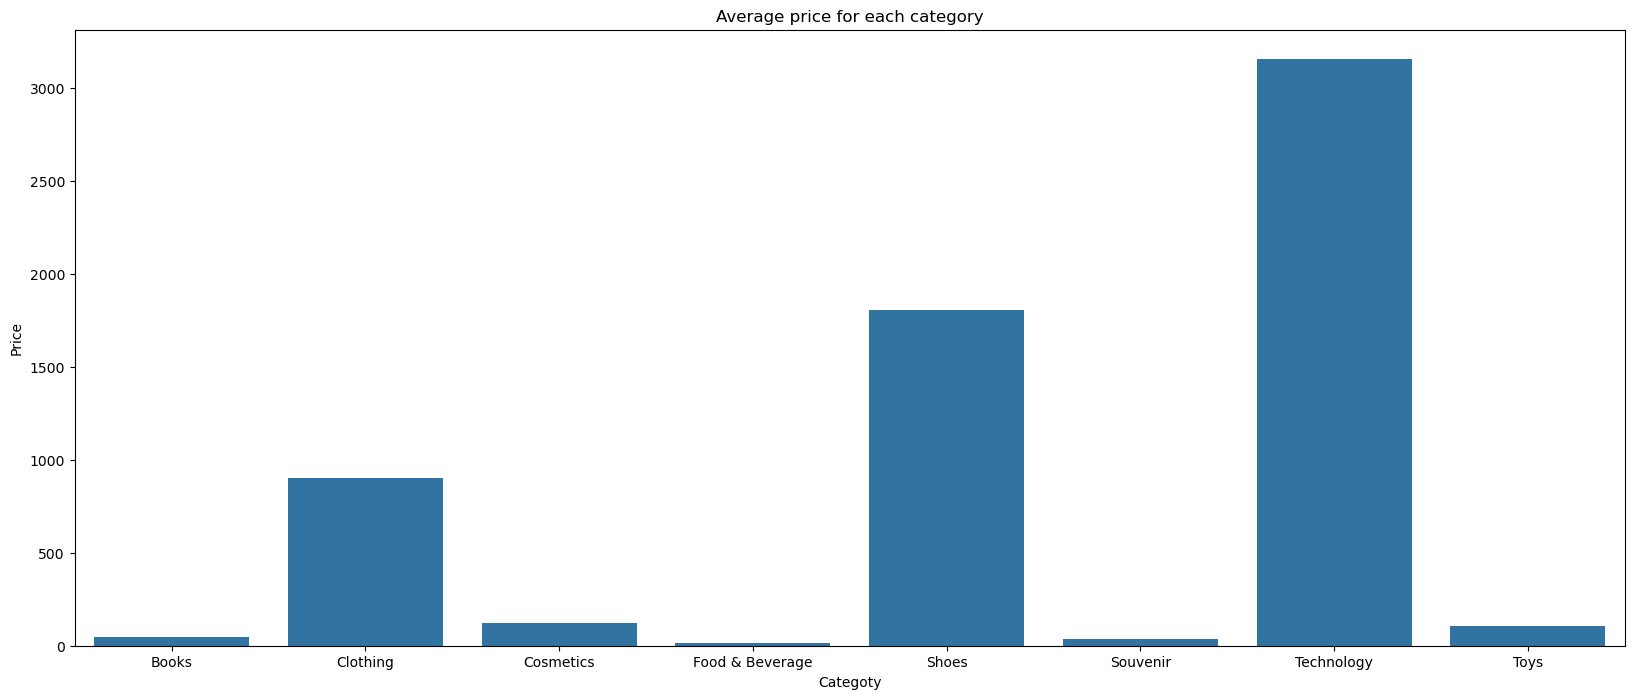

In [45]:
# Average price for each category
plt.figure(figsize=(20,8))
plt.title('Average price for each category')
sns.barplot(x='category',y='price',data=avg_price)
plt.xlabel('Categoty')
plt.ylabel('Price')

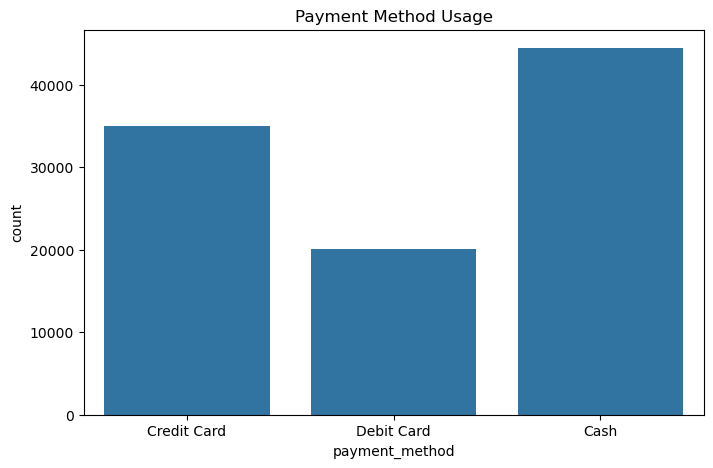

In [46]:
# Payment Method Analysis
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='payment_method')
plt.title("Payment Method Usage")
plt.show()

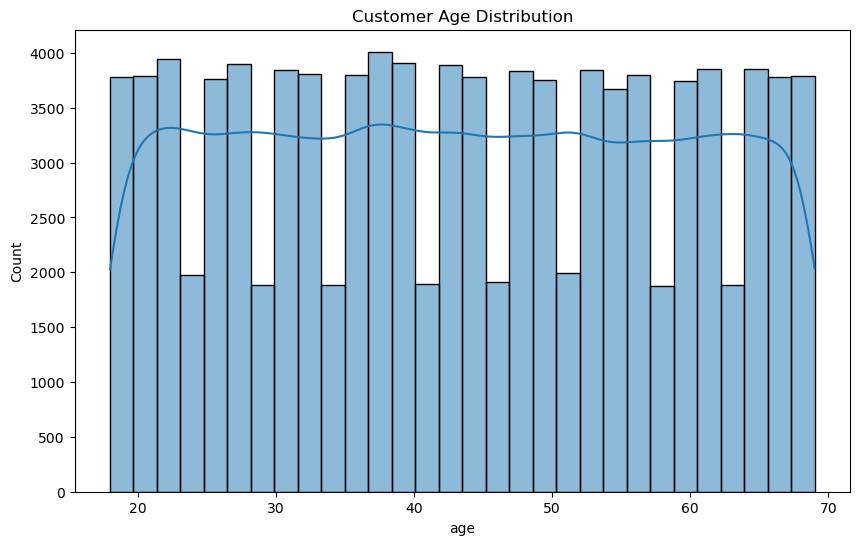

In [47]:
# Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Customer Age Distribution")
plt.show()

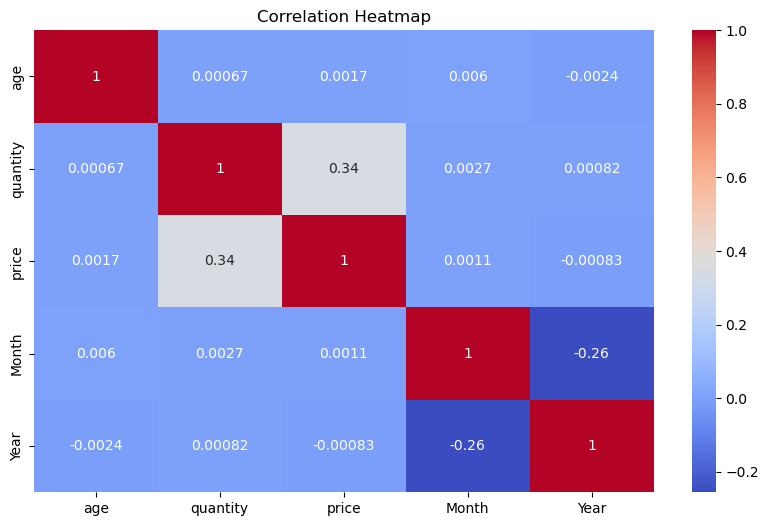

In [48]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


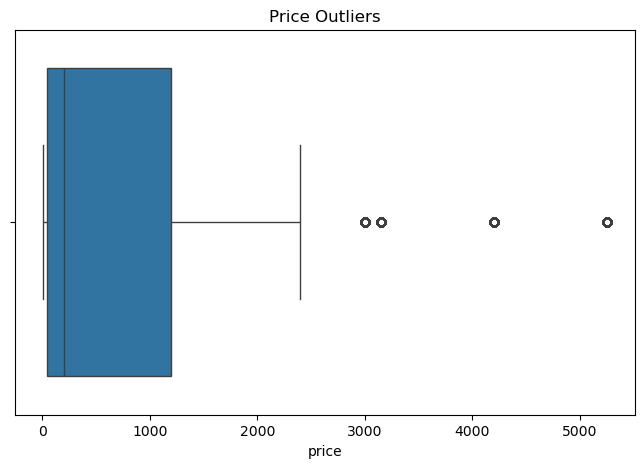

In [49]:
# Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df['price'])
plt.title("Price Outliers")
plt.show()

In [50]:
# Top Shopping Malls
top_malls = df['shopping_mall'].value_counts().head(10)

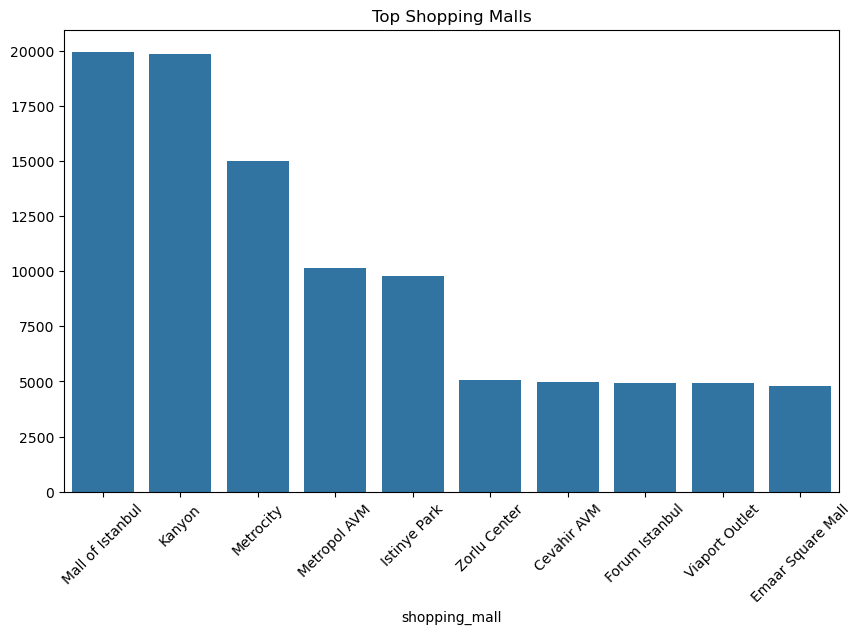

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_malls.index, y=top_malls.values)
plt.title("Top Shopping Malls")
plt.xticks(rotation=45)
plt.show()

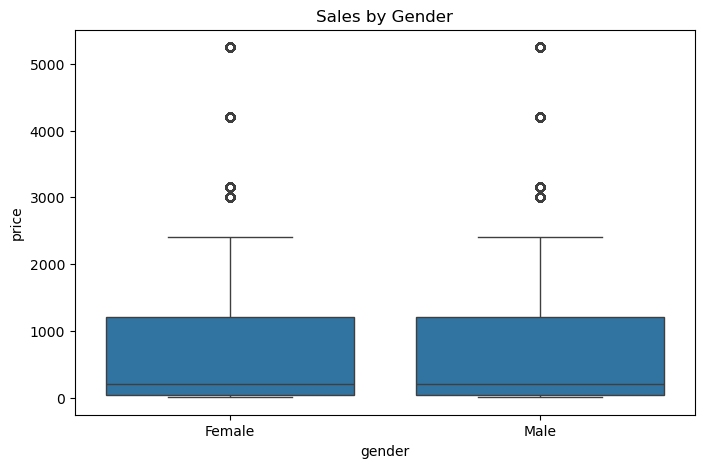

In [52]:
# Sales by Gender
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='gender', y='price')
plt.title("Sales by Gender")
plt.show()

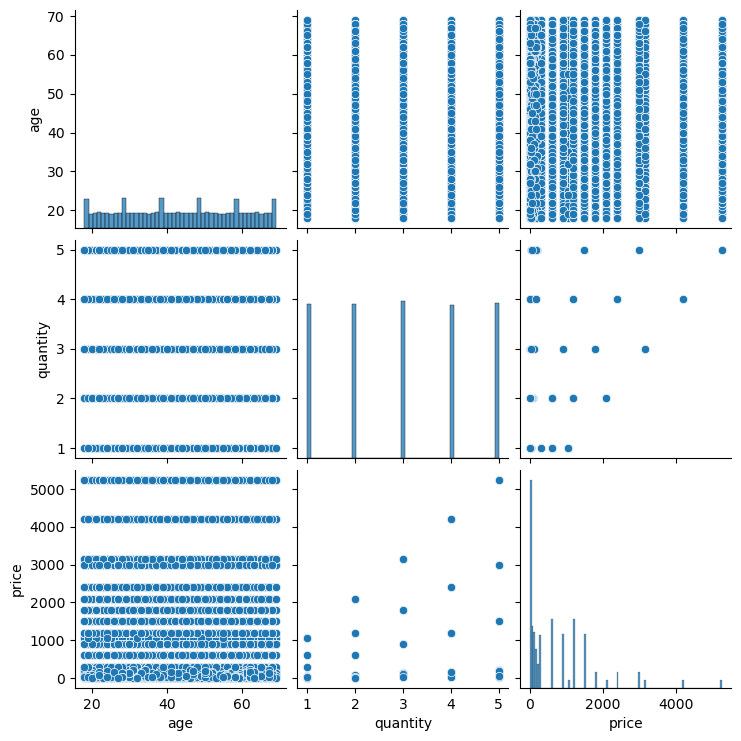

In [53]:
# Pairplot
sns.pairplot(df[['age', 'quantity', 'price']])
plt.show()

In [54]:
# Insights
print("\nKey Insights:")
print("1. Certain categories generate significantly higher sales.")
print("2. Monthly sales reveal seasonal purchasing patterns.")
print("3. Some customers make extremely high purchases (outliers).")
print("4. Credit card payments are the most commonly used.")


Key Insights:
1. Certain categories generate significantly higher sales.
2. Monthly sales reveal seasonal purchasing patterns.
3. Some customers make extremely high purchases (outliers).
4. Credit card payments are the most commonly used.


# Summary of Insights

## 1. Sales Trends

##### Certain product categories generated significantly higher revenue compared to others.
##### Monthly sales analysis revealed noticeable seasonal purchasing behavior.
##### Sales increased during specific months, indicating peak shopping periods.

## 2. Customer Behavior Insights

##### Customers within the middle-age group contributed the highest number of purchases.
##### Female and male purchasing behaviors showed slight differences in spending patterns.
##### Repeat purchasing behavior was visible in high-frequency customer segments.

## 3. Payment Method Analysis

##### Credit card payments were the most preferred payment method among customers.
##### Online payment methods showed higher transaction frequency compared to cash payments.

## 4. Outlier Detection

##### Several extreme purchase values were identified through boxplot analysis.
##### These outliers may represent bulk purchases, premium customers, or potential data anomalies.
##### Outlier handling is important for improving future predictive modeling accuracy.

## 5. Correlation Findings

##### Positive correlation existed between quantity purchased and total sales amount.
##### Some variables showed weak relationships, indicating independent customer behavior factors.

## 6. Shopping Mall / Store Performance

##### A few shopping malls consistently outperformed others in total revenue generation.
##### High-performing locations can be targeted for future marketing campaigns and inventory expansion.

# Final Conclusion

##### The exploratory data analysis successfully identified customer purchasing patterns, high-performing product categories, seasonal sales trends, and spending outliers. The analysis provides valuable business insights that can help organizations improve marketing strategies, optimize inventory management, and better understand customer behavior for data-driven decision-making.